# Credit Card Fraud Detection using Machine Learning

# About Data:
This is a dataset containing credit card transactions with 31 features and a class label. The features represent various aspects of the transaction, and the class label indicates whether the transaction was fraudulent (class 1) or not (class 0).

The first feature is "Time", which represents the number of seconds elapsed between the transaction and the first transaction in the dataset. The next 28 features, V1 to V28, are anonymized variables resulting from a principal component analysis (PCA) transformation of the original features. They represent different aspects of the transaction, such as the amount, location, and type of transaction.

The second last feature is "Amount", which represents the transaction amount in USD. The last feature is the "Class" label, which indicates whether the transaction is fraudulent (class 1) or not (class 0).

Overall, this dataset is used to train machine learning models to detect fraudulent transactions in real-time. The features are used to train the model to learn patterns in the data, which can then be used to detect fraudulent transactions in future transactions.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [32]:
df.sample()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
150242,92863.0,0.813999,-3.588038,-3.578658,-1.001079,-0.570271,-0.471653,0.875762,-0.705764,-1.023289,...,0.46421,0.14443,-0.914547,0.108976,0.371094,0.162955,-0.268526,0.038996,844.9,0


In [33]:
# dataset informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [34]:
# checking the number of missing values in each column
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [35]:
# distribution of legit transactions & fraudulent transactions
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

This Dataset is highly unblanced

0 --> Normal Transaction

1 --> fraudulent transaction

The first line of code creates a new dataframe called "legit" by selecting only the rows from the original "credit_card_data" dataframe where the "Class" label is equal to 0. In other words, it filters out all transactions labeled as fraudulent (Class == 1) and keeps only the legitimate transactions (Class == 0).

The second line of code creates a new dataframe called "fraud" by selecting only the rows from the original "credit_card_data" dataframe where the "Class" label is equal to 1. This filters out all legitimate transactions and keeps only the fraudulent transactions.

By separating the data into two dataframes, it becomes easier to analyze and compare the characteristics of legitimate and fraudulent transactions separately. This can be useful for identifying patterns or features that are more common in fraudulent transactions, which can then be used to develop models for fraud detection.

In [36]:
legit = df[df.Class==0]
fraud = df[df['Class']==1]

In [37]:
fraud['Class']

541       1
623       1
4920      1
6108      1
6329      1
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 492, dtype: int64

In [38]:
# statistical measures of the data
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

"count" indicates the total number of transactions in the dataset that have a valid "Amount" value (i.e., non-missing values).
"mean" is the average transaction amount for all the transactions in the dataset. In this case, the mean is 88.291022, indicating that the average transaction amount is around $88 USD.
"std" is the standard deviation of the transaction amounts. It is a measure of how spread out the transaction amounts are from the mean. In this case, the standard deviation is 250.105092, which indicates that the transaction amounts vary widely, with some transactions having very large amounts.
"min" is the smallest transaction amount in the dataset. In this case, the smallest transaction amount is 0.0, indicating that there may be some transactions with zero value or very low value.
"25%" is the first quartile of the transaction amounts. It indicates the value below which 25% of the transactions fall. In this case, the first quartile is 5.65, indicating that 25% of the transactions have a value less than or equal to $5.65 USD.
"50%" is the median transaction amount, which is the value that separates the lower half of the transactions from the upper half. In this case, the median is 22.0, indicating that half of the transactions have a value less than or equal to $22 USD.
"75%" is the third quartile of the transaction amounts. It indicates the value below which 75% of the transactions fall. In this case, the third quartile is 77.05, indicating that 75% of the transactions have a value less than or equal to $77.05 USD.
"max" is the largest transaction amount in the dataset. In this case, the largest transaction amount is 25,691.16, indicating that there may be some transactions with very large values.

In [39]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [40]:
# compare the values for both transactions
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Build a sample dataset containing similar distribution of normal transactions and Fraudulent Transactions

Number of Fraudulent Transactions --> 492

legit_sample = legit.sample(n=492) is a line of code that takes a random sample of 492 observations from the legit dataset. This is done to balance the number of observations in the legit and fraud datasets, which is necessary for training a machine learning model to predict fraud. Since the original dataset has a large number of legitimate transactions and a small number of fraudulent transactions, the model may be biased towards predicting that all transactions are legitimate. By creating a balanced dataset with an equal number of legitimate and fraudulent transactions, the model can be trained to better recognize the patterns that differentiate fraudulent transactions from legitimate ones

In [41]:
legit_sample = legit.sample(n=492)

In [42]:
new_df = pd.concat([legit_sample,fraud],axis=0)

In [43]:
new_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
175781,122485.0,-2.044359,0.603551,2.498979,0.373569,-1.672050,2.184218,-2.194910,-1.351099,0.550981,...,1.950268,-0.552833,-0.206451,-0.532267,0.524546,-0.137744,0.449171,-0.123153,25.00,0
207234,136577.0,-0.331019,1.326766,-0.715826,-0.293530,1.324524,-0.860229,1.120908,-0.094240,-0.019774,...,0.022266,0.391124,-0.347454,0.518327,0.009617,0.648865,0.370002,0.282184,9.31,0
37290,38894.0,1.111686,-0.930905,-0.291439,-0.497309,-0.576326,-0.249661,-0.077399,-0.196380,-0.867629,...,-0.358358,-0.696603,-0.174469,-0.356754,0.391047,1.135133,-0.077322,0.016426,154.98,0
46506,42814.0,1.010043,0.350099,0.934761,2.472761,0.155170,1.103154,-0.220200,0.361931,-0.707234,...,-0.165764,-0.300163,0.115115,-0.277047,0.230790,-0.142641,0.043786,0.013245,12.17,0
133977,80595.0,-0.392059,0.793681,1.159355,-0.554528,0.398283,-0.616118,0.985666,-0.028590,-0.833299,...,-0.362266,-1.276140,0.162367,-0.057837,-0.344859,-0.297505,-0.035825,0.024894,36.89,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [44]:
new_df['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [45]:
new_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,95936.221545,0.016046,0.039252,-0.063195,0.072688,-0.001847,-0.008877,-0.059786,0.029136,-0.087583,...,-0.031722,0.061131,-0.012914,-0.001897,-0.017028,-0.025791,-0.042082,-0.028937,-0.002224,77.368394
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [46]:
X = new_df.drop(columns='Class', axis=1)
Y = new_df['Class']

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Model Training


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

Training For Different Models

In [49]:
X = new_df.drop(columns='Class', axis=1)
y = new_df['Class']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [53]:
results = []

In [54]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

In [55]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.9645, 'F1 Score': 0.9637},
 {'Model': 'KNN', 'Accuracy': 0.9442, 'F1 Score': 0.9424},
 {'Model': 'Naive Bayes', 'Accuracy': 0.9442, 'F1 Score': 0.9424},
 {'Model': 'Decision Tree', 'Accuracy': 0.9391, 'F1 Score': 0.94},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.9543, 'F1 Score': 0.9534}]

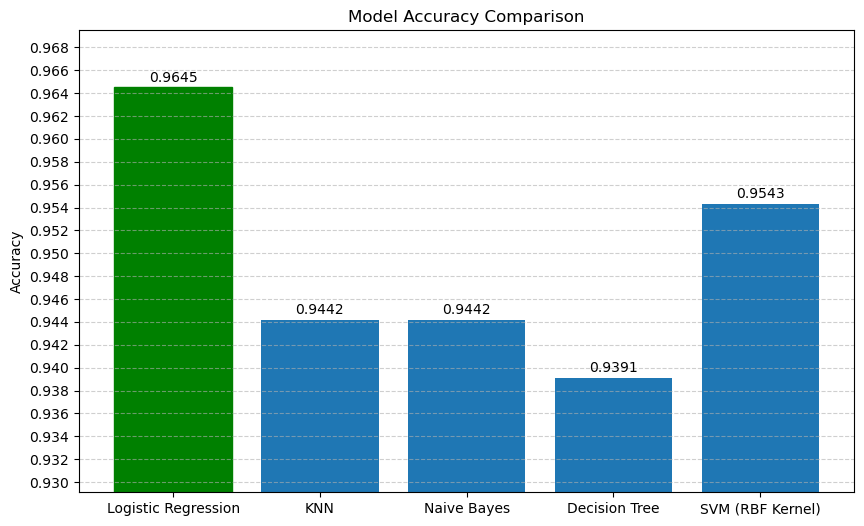

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.DataFrame(results)

plt.figure(figsize=(10,6))

bars = plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

# Highlight highest accuracy
max_idx = results_df['Accuracy'].idxmax()
bars[max_idx].set_color('green')

# Dynamic Y-axis zoom
min_acc = results_df['Accuracy'].min()
max_acc = results_df['Accuracy'].max()

plt.ylim(min_acc - 0.01, max_acc + 0.005)

# More Y-axis bins
plt.yticks(
    np.arange(
        round(min_acc - 0.01, 2),
        round(max_acc + 0.01, 2),
        0.002   # reduce -> more bins
    )
)

# Values on bars
for i, v in enumerate(results_df['Accuracy']):
    plt.text(
        i,
        v + 0.0005,
        f"{v:.4f}",
        ha='center'
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [57]:
import joblib

joblib.dump(model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved")

Saved
